# COMP9444 SR Group Project Report
## IMDb Sentiment Classification

**Group members:**

Sizheng Rao (z5636931)

Zehao Zheng(z5546836)

Zhetao Sheng(z5574315)

Yifan Dong (z5619063)

Zhide Ren (z5661093)

# 0. How to use

The project root directory contains five folders, each corresponding to one of the five evaluated models:

* Logistic Regression                 [LR.ipynb](./LR/LR.ipynb)
* Naive Bayes                         [Naive Bayes.ipynb](./Naive_bayes/Naive%20Bayes.ipynb)
* Embedding–TextCNN                   [Main_Embedding_CNN.ipynb](./Embedding_CNN/Main_Embedding_CNN.ipynb)
* BiLSTM                              [README.md](./BiLSTM/README.md)
* Large Language Model(Qwen3-0.6B)    [4ipynbs under root](./Qwen3_0.6B_IMDB/)

All notebooks, scripts, saved models, results, and supporting files for each model are stored within its corresponding folder. To inspect or reproduce a model, open that folder and run its main notebook in order.


# 1. Introduction, Motivation and Problem Statement

## 1.1 Problem Statement

Online reviews provide valuable information about users’ opinions, preferences, and satisfaction. However, platforms such as IMDb contain a large volume of user-generated reviews, making manual analysis time-consuming, inconsistent, and prone to error. Automated sentiment analysis offers an efficient way to determine whether audience responses are positive or negative, supporting film studios, marketers, and recommendation systems in understanding public opinion and making data-driven decisions.

Sentiment classification remains challenging because the meaning of a review cannot always be determined from isolated words. Negation, word combinations, contextual meaning, long-range dependencies, and implicit expressions can all influence the overall sentiment. Different approaches represent and process these features differently. Therefore, this project investigates not only classification performance, but also how text representation and model design affect the results.

## 1.2 Project Motivation

This project aims to develop and evaluate a range of natural language processing methods for classifying IMDb movie reviews as either positive or negative. The investigated methods range from a simple baseline and traditional machine learning classifiers, including Logistic Regression and Naive Bayes, to neural approaches based on TextCNN with different embedding strategies and BiLSTM, as well as a large language model inference approach.

These methods represent different ways of processing text. Traditional classifiers rely on statistical text features, the embedding study examines how pretrained word representations affect TextCNN, BiLSTM models sequential information in both directions, and the large language model performs sentiment classification through inference. Their comparison allows the project to examine the effects of text representation, model architecture, and model complexity on sentiment classification performance.

## 1.3 Project Objectives

The objectives of this project are to:

1. Develop models that classify IMDb movie reviews as positive or negative.
2. Compare traditional machine learning, neural network, and large language model approaches.
3. Investigate how text representation, including semantic and sentiment-related embedding information, affects neural classification performance.
4. Evaluate the models using accuracy, precision, recall, and F1-score.
5. Analyse misclassified reviews to identify common challenges and model limitations.
6. Discuss the trade-offs between predictive performance, model complexity, training data requirements, and computational cost.

# 2. Data Sources and Task Definition

## 2.1 IMDb Dataset Overview

The IMDb Movie Reviews dataset was used in this project. It is a binary sentiment analysis dataset containing 50,000 labelled movie reviews, with an equal number of positive and negative samples. Reviews with ratings of 4 or below are labelled as negative, while reviews with ratings of 7 or above are labelled as positive. Neutral reviews are not included. To reduce potential bias towards individual movies, no more than 30 reviews are collected for each movie.

The dataset contains an official training set of 25,000 labelled reviews and a test set of 25,000 labelled reviews. An additional 50,000 unlabelled reviews are also available. The dataset was obtained from:

https://huggingface.co/datasets/Kwaai/IMDB_Sentiment

## 2.2 Task Definition

The task is to predict the sentiment of an IMDb movie review based on its textual content. Each review is classified into one of two classes:

- Positive
- Negative

The input to each method is the review text, and the expected output is its predicted sentiment label. Model performance is evaluated using accuracy, precision, recall, and F1-score.


## 2.3 Dataset Split and Usage

The official 25,000-review training set was divided into:

- 20,000 reviews for model training;
- 5,000 reviews for validation and model selection.

The official 25,000-review test set was retained for final evaluation.

The additional 50,000 unlabelled reviews were used only in the relevant embedding-pretraining experiment and were not used as labelled examples for classifier training.

Validation and test labels were not used during model training.

# 3. Exploratory Analysis and Pre-processing

## 3.1 Common Dataset Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from datasets import load_dataset
from IPython.display import display
from tqdm.auto import tqdm

SEED = 42
SPLIT_ORDER = ["Train", "Validation", "Test"]

sns.set_theme(style="whitegrid")


c:\Users\lulu\anaconda3\envs\yolo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASET_ID = "Kwaai/IMDB_Sentiment"

raw_dataset = load_dataset(
    DATASET_ID,
    download_mode="force_redownload",
)
for split_name, dataset in raw_dataset.items():
    print(
        f"{split_name:<15}"
        f"{len(dataset):>8,} reviews | "
        f"columns: {dataset.column_names}"
    )

Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 485415.90 examples/s]


train            25,000 reviews | columns: ['text', 'label']
test             25,000 reviews | columns: ['text', 'label']
unsupervised     50,000 reviews | columns: ['text', 'label']


### 3.1.1 Class Distribution

The labelled dataset contains 25,000 negative and 25,000 positive reviews. The training, validation, and test splits retain the same balanced class distribution.

In [3]:
train_valid_split = raw_dataset["train"].train_test_split(
    test_size=5000,
    seed=SEED,
    stratify_by_column="label",
)

train_dataset = train_valid_split["train"]
valid_dataset = train_valid_split["test"]
test_dataset = raw_dataset["test"]

unlabelled_dataset = raw_dataset["unsupervised"]

datasets = {
    "Train": train_dataset,
    "Validation": valid_dataset,
    "Test": test_dataset,
}
class_rows = []

for split_name, dataset in datasets.items():
    counts = np.bincount(
        dataset["label"],
        minlength=2,
    )

    class_rows.append({
        "Split": split_name,
        "Negative": int(counts[0]),
        "Positive": int(counts[1]),
        "Total": int(counts.sum()),
    })

class_counts = (
    pd.DataFrame(class_rows)
    .set_index("Split")
    .reindex(SPLIT_ORDER)
)

class_counts.loc["Overall"] = class_counts.sum()

display(class_counts)

,Negative,Positive,Total
Split,,,
Train,10000,10000,20000
Validation,2500,2500,5000
Test,12500,12500,25000
Overall,25000,25000,50000


### 3.1.2 Review Length Distribution

Review lengths are strongly right-skewed, with most reviews containing approximately 100–300 words and a small number being substantially longer. The mean length is around 230 words, while the median is approximately 173 words. Train, validation, and test sets show similar distributions, suggesting that the data split introduces no noticeable length bias.

In [4]:
length_data = []
all_tokens = []

for split_name, dataset in datasets.items():
    for text in dataset["text"]:
        tokens = text.split()

        length_data.append([
            split_name,
            len(tokens),
        ])

        all_tokens.extend(tokens)

length_df = pd.DataFrame(
    length_data,
    columns=["Split", "Length"],
)

token_counts = Counter(all_tokens)

In [5]:
display(
    length_df
    .groupby("Split")["Length"]
    .describe()
    .round(1)
)

print("Total reviews:", len(length_df))
print("Total tokens:", len(all_tokens))
print("Unique tokens:", len(token_counts))

,count,mean,std,min,25%,50%,75%,max
Split,,,,,,,,
Test,25000.0,228.5,168.9,4.0,126.0,172.0,277.0,2278.0
Train,20000.0,234.1,173.9,10.0,127.0,174.0,284.0,2470.0
Validation,5000.0,232.5,173.2,15.0,126.0,173.0,285.0,1723.0


Total reviews: 50000
Total tokens: 11557847
Unique tokens: 438729


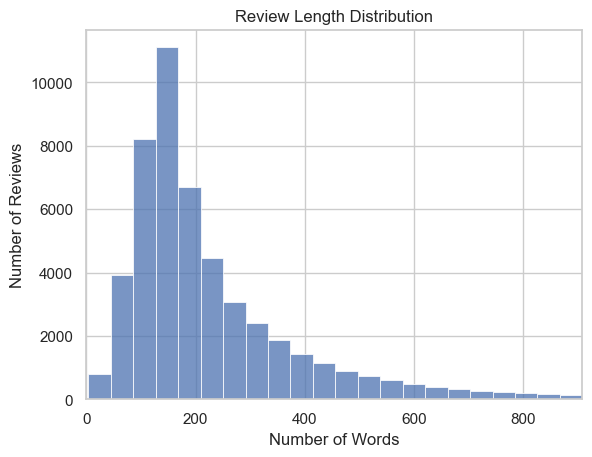

In [6]:
sns.histplot(
    data=length_df,
    x="Length",
    bins=60,
)

plt.xlim(0, length_df["Length"].quantile(0.99))
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

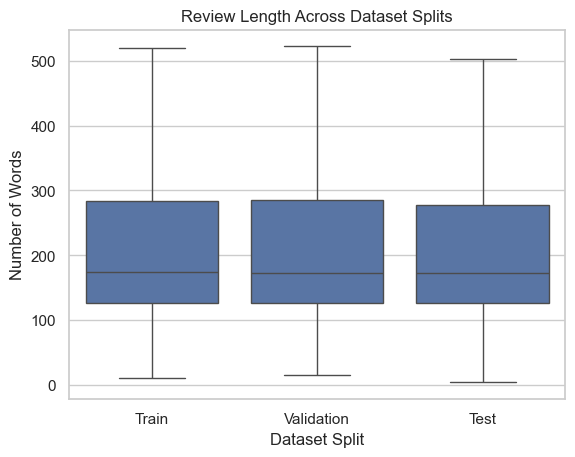

In [7]:
sns.boxplot(
    data=length_df,
    x="Split",
    y="Length",
    showfliers=False,
)

plt.title("Review Length Across Dataset Splits")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Words")
plt.show()

### 3.1.3 Vocabulary Characteristics

Across the 50,000 labelled reviews, the dataset contains approximately 11.56 million whitespace-separated token occurrences and 438,729 unique raw tokens. The vocabulary exhibits a strong long-tail distribution: 268,869 tokens occur only once, while 371,909 occur no more than five times, accounting for 84.77% of all unique tokens. In contrast, only 7,640 tokens appear more than 100 times.

This high proportion of rare tokens indicates substantial vocabulary sparsity. Since the statistics are based on raw whitespace tokenisation, differences in capitalisation and punctuation, together with HTML fragments, spelling errors, names and uncommon expressions, are counted separately. This presents a generalisation challenge and motivates model-specific text preprocessing and vocabulary handling in the later methods.


In [8]:
frequencies = np.array(
    list(token_counts.values())
)

vocabulary_summary = pd.DataFrame({
    "Metric": [
        "Total token occurrences",
        "Unique tokens",
        "Tokens occurring once",
        "Tokens occurring at most five times",
        "Rare-token proportion",
    ],
    "Value": [
        len(all_tokens),
        len(token_counts),
        (frequencies == 1).sum(),
        (frequencies <= 5).sum(),
        (frequencies <= 5).mean(),
    ],
})

print(f"Total token occurrences: {len(all_tokens):,}")
print(f"Unique tokens: {len(token_counts):,}")
print(f"Tokens occurring once: {(frequencies == 1).sum():,}")
print(f"Tokens occurring at most five times: {(frequencies <= 5).sum():,}")
print(f"Rare-token proportion: {(frequencies <= 5).mean():.2%}")

Total token occurrences: 11,557,847
Unique tokens: 438,729
Tokens occurring once: 268,869
Tokens occurring at most five times: 371,909
Rare-token proportion: 84.77%


In [9]:
top_tokens = pd.DataFrame(
    token_counts.most_common(15),
    columns=["Token", "Frequency"],
)

display(top_tokens)

,Token,Frequency
0,the,568735
1,a,306960
2,and,301919
3,of,283625
4,to,261850
5,is,203056
6,in,169981
7,I,132498
8,that,126818
9,this,113726


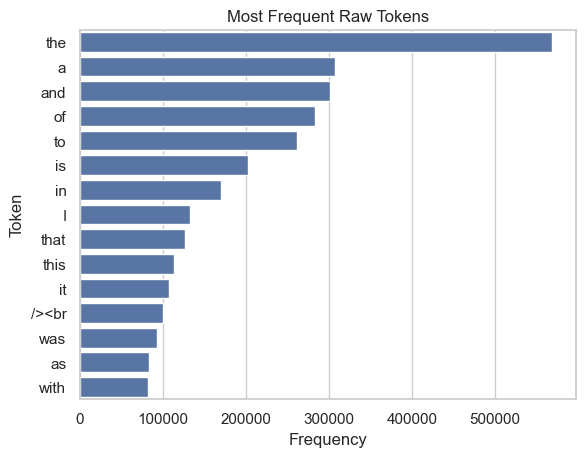

In [10]:
sns.barplot(
    data=top_tokens,
    x="Frequency",
    y="Token",
)

plt.title("Most Frequent Raw Tokens")
plt.xlabel("Frequency")
plt.ylabel("Token")
plt.show()

In [11]:
frequency_bands = pd.Series({
    "Once": (frequencies == 1).sum(),
    "2–5 times": (
        (frequencies >= 2)
        & (frequencies <= 5)
    ).sum(),
    "6–10 times": (
        (frequencies >= 6)
        & (frequencies <= 10)
    ).sum(),
    "11–100 times": (
        (frequencies >= 11)
        & (frequencies <= 100)
    ).sum(),
    "More than 100": (
        frequencies > 100
    ).sum(),
})

display(
    frequency_bands
    .rename("Number of unique tokens")
    .to_frame()
)

,Number of unique tokens
Once,268869
2–5 times,103040
6–10 times,24168
11–100 times,35012
More than 100,7640


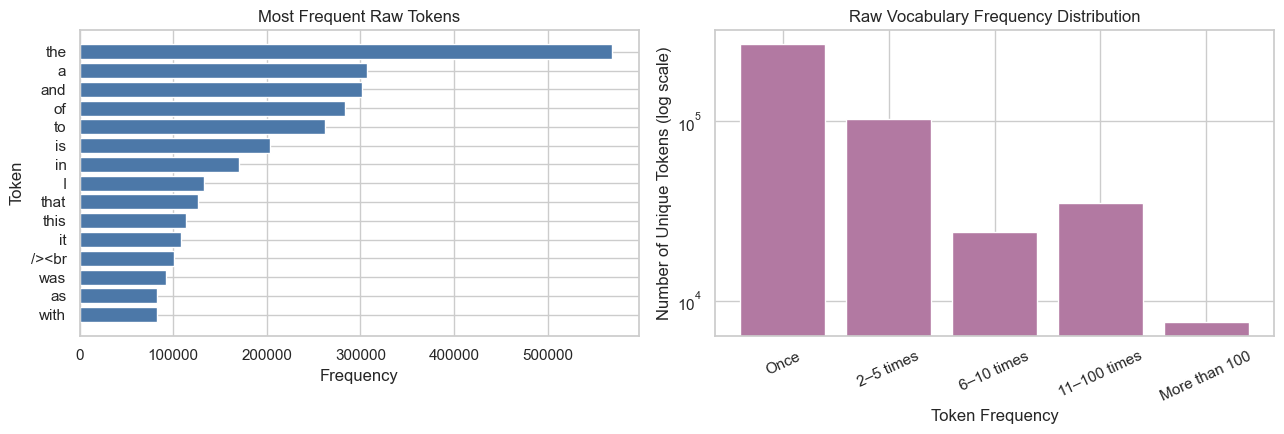

In [12]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
)

top_tokens_plot = top_tokens.sort_values(
    "Frequency"
)

axes[0].barh(
    top_tokens_plot["Token"],
    top_tokens_plot["Frequency"],
    color="#4C78A8",
)

axes[0].set_title("Most Frequent Raw Tokens")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Token")

axes[1].bar(
    frequency_bands.index,
    frequency_bands.values,
    color="#B279A2",
)

axes[1].set_yscale("log")
axes[1].set_title("Raw Vocabulary Frequency Distribution")
axes[1].set_xlabel("Token Frequency")
axes[1].set_ylabel("Number of Unique Tokens (log scale)")
axes[1].tick_params(
    axis="x",
    rotation=25,
)

plt.tight_layout()
plt.show()

### 3.1.4 Linguistic Challenges

- Negation；
- Mixed sentiment；
- Context-dependent meaning；
- Sarcasm and implicit sentiment；
- Rare and out-of-vocabulary words；
- Long reviews and information truncation。

## 3.2 Pre-processing for Logistic Regression

Since Logistic Regression cannot directly process raw text, all movie reviews were first converted into numerical feature vectors using the TF-IDF (Term Frequency–Inverse Document Frequency) representation. Every review was first cleaned by removing HTML line-break tags `<br />` and normalising whitespace.

A unigram representation was adopted, making each feature corresponds to a single word. To control the dimensionality of the feature space and improve computational efficiency, the vocabulary was limited to the 5,000 most informative terms. The TF-IDF vectoriser was fitted only on the training set, and the resulting vocabulary and IDF statistics were reused to transform the validation and test sets. This ensures that no information from unseen data is introduced during feature extraction and provides a consistent input representation for the Logistic Regression classifier.

## 3.3 Pre-processing for Naive Bayes

For Naive Bayes, each review was converted to lowercase to reduce duplicate word forms. HTML line-break tags (`<br>`) were replaced with spaces, consecutive whitespace was normalised, and leading/trailing whitespace was removed. The same cleaning procedure was applied consistently to the training, validation, and test sets.

## 3.4 Pre-processing for Embedding–TextCNN

seed=42

### 3.4.1 Text Normalisation and Tokenisation

- Decode HTML entities.
- Replace `<br>` tags with spaces.
- Lowercase.
- Regular-expression tokenisation.
- Retain alphabetic words, contracts, consecutive exclamation marks or question marks, and emoticons.
- Not using stemming or lemmatisation.

### 3.4.2 Vocabulary Construction

- The vocabulary was built using only 20,000 labelled training reviews.
- The top 50 most frequent words were removed.
- Some specific words were preserved in `PROTECTED_TOKENS`.eg:'not'
- `<pad>` and `<unk>` were added.
- The same vocabulary was used across all four experimental groups.
- **8,000** lexical tokens were retained.


![vocabulary.png](./Embedding_CNN/pic/vocabulary_size.png)

- A vocabulary size of 8,000 lexical tokens was selected as a practical trade-off between token coverage and model size. It covered 88.37% of the eligible token occurrences in the validation set, while the least frequent retained tokens still appeared 33 times in the training corpus. 

### 3.4.3 Review Encoding
- Convert tokens to vocabulary IDs.
- The current implementation omits tokens outside the vocabulary.
- If no tokens are preserved for the entire comment, use `<unk>`.
- Preserve the original token order for use by TextCNN.

### 3.4.4 Padding and Truncation

- Encoded reviews were truncated to the first 1000 retained token IDs. Within each mini-batch, sequences were dynamically padded to the length of the longest sequence using the `<pad>` token, thereby avoiding unnecessary padding to the global maximum length.
- 1000 is a conservative length, ensuring 99.99% of the information is retained.


![CNN_sequence_length.png](./Embedding_CNN/pic/CNN_sequence_length.png)

### 3.4.5 Processing of Unlabelled Reviews

- Uses the same tokenizer.
- Uses a fixed vocabulary built from the labelled training set.
- Only used in the relevant embedding pre-training set.
- Not used as labelled training examples for CNNs.


### 3.4.6 Pre-processing Limitations

- Lowercasing may result in the loss of capitalization cues.
- Omitting OOV tokens may lead to the loss of rare sentiment expressions.
- Embedding in pre-trained document-level word-count representation does not preserve word order.

## 3.5 Pre-processing for BiLSTM

### 3.5.1 What this subsection covers
Raw IMDb reviews cannot be fed directly into the BiLSTM. They first need to be transformed into a consistent sequence format that can be batched, padded, masked, and mapped into embeddings. In this project, preprocessing is intentionally conservative: the aim is to reduce formatting noise and produce stable token sequences without aggressively rewriting the semantic content of the reviews.

### 3.5.2 Pipeline summary
The implemented pipeline consists of six main steps. First, the raw text is normalized by removing HTML break markers such as `<br />`, compressing repeated whitespace, and lowercasing the review. Second, the normalized review is tokenized into an ordered token sequence. Third, a vocabulary is built from the training data, with special tokens such as `<pad>` and `<unk>` reserved. Fourth, each tokenized review is converted into a sequence of integer token IDs. Fifth, sequences are padded within a batch and a mask is created so that padded positions can be ignored during sequence aggregation. Finally, the vocabulary and processed examples are saved as reusable artifacts.

### 3.5.3 Why these steps matter for the BiLSTM
These steps are directly motivated by the needs of a recurrent architecture. The encoder requires an ordered sequence rather than an unordered bag of words, so token order must be preserved. Padding and masking are necessary because review lengths vary substantially, but the batch must still be represented in a rectangular tensor. Conservative normalization helps remove clearly irrelevant variation while preserving sentiment-bearing phrasing. Saving the vocabulary and processed artifacts also improves reproducibility, because the same token-to-id mapping can be reused consistently during training and evaluation.

### 3.5.4 Evidence from the implementation
This subsection is grounded in `src/data/preprocess.py`, `src/data/collate.py`, and `data/vocab.json`. The code below shows one concrete raw review, its normalized form, its initial tokens, and the corresponding token IDs under the saved vocabulary.

In [23]:
import sys

sys.path.insert(0, 'BiLSTM')

from src.data.preprocess import load_text_column_from_parquet, normalize_text, tokenize_text, text_to_ids
from src.data.vocab import load_vocab

train_path = './BiLSTM/data/raw/train-00000-of-00001.parquet'
vocab_path = './BiLSTM/data/vocab.json'

raw_texts = load_text_column_from_parquet(train_path)
vocab = load_vocab(vocab_path)
raw_example = raw_texts[0]
normalized_example = normalize_text(raw_example, lowercase=True)
tokens = tokenize_text(normalized_example)
token_ids = text_to_ids(raw_example, vocab=vocab, lowercase=True)

summary_df = pd.DataFrame(
    {
        'item': ['vocab_size', 'raw_review_count', 'example_token_count'],
        'value': [len(vocab), len(raw_texts), len(tokens)],
    }
)
summary_df

print('RAW EXAMPLE (first 600 chars):')
print(raw_example[:600])
print('\nNORMALIZED EXAMPLE (first 600 chars):')
print(normalized_example[:600])
print('\nFIRST 40 TOKENS:')
print(tokens[:40])
print('\nFIRST 40 TOKEN IDS:')
print(token_ids[:40])

RAW EXAMPLE (first 600 chars):
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political is

NORMALIZED EXAMPLE (first 600 chars):
i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in 1967. i also heard that at first it was seized by u.s. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" i really had to see this for myself. th

## 3.6 Input Preparation for LLM Inference(Qwen3-0.6B)

- For LoRA, the shared labelled training portion was split with seed 42 and stratification into **20,000 training** and **5,000 validation** reviews.
- HTML line breaks were removed and whitespace was normalised. Stop words, punctuation and negation terms were otherwise retained because they carry sentiment and discourse information.
- Prompting retained equal head and tail token segments when a review exceeded **900 review tokens**. This preserves both the opening context and the concluding verdict.
- LoRA used a **430-review-token budget** inside a maximum sequence length of 512. This smaller budget was required by the training memory constraint.

A strict output parser treated anything other than `positive` or `negative` as invalid.

In [ ]:
# Key Qwen-specific preprocessing functions.
import re

def clean_review(text: str) -> str:
    text = re.sub(r"<br\s*/?>", " ", str(text), flags=re.IGNORECASE)
    return re.sub(r"\s+", " ", text).strip()

def truncate_head_tail(text: str, tokenizer, max_tokens: int) -> str:
    text = clean_review(text)
    token_ids = tokenizer.encode(text, add_special_tokens=False)
    if len(token_ids) <= max_tokens:
        return text
    head = max_tokens // 2
    tail = max_tokens - head
    kept_ids = token_ids[:head] + token_ids[-tail:]
    return tokenizer.decode(kept_ids, skip_special_tokens=True)

# 4. Models and Methods

## 4.1 Logistic Regression

### 4.1.1 Method Overview

This project adopts a traditional machine learning pipeline for binary sentiment classification. The overall framework is inspired by the TF-IDF and Logistic Regression approach proposed by Ramdan et al., who used TF-IDF to transform movie reviews into numerical feature vectors before classification.
Unlike the referenced work, which applies the scikit-learn Logistic Regression classifier with predefined parameters, this project develops a custom Logistic Regression classifier.In addition, hyperparameter tuning is performed using a validation set to determine the optimal learning rate, L2 regularisation strength and training epochs before retraining the final model on the complete training dataset.

And the overall pipeline of LR is as follows:

> Cleaning Data → TF-IDF Vectorisation → Linear Transformation → Sigmoid Activation → Binary Prediction



### 4.1.2 TF-IDF Feature Extraction

The cleaned movie reviews are transformed into numerical feature vectors using TF-IDF. This representation measures the importance of each word according to both its frequency within a review and its rarity across the corpus, allowing informative words to receive larger weights.
In this implementation, all text is converted to lowercase and unigram features are adopted (`ngram_range=(1,1)`). The vocabulary size is limited to the 5,000 most informative terms to reduce computational cost while preserving representative features. The TF-IDF vectoriser is fitted only on the training data and reused to transform the validation and test sets, preventing data leakage.

### 4.1.3 Logistic Regression

For each TF-IDF feature vector x, the model first computes a linear transformation. The sigmoid activation function is then applied to estimate the probability of the review belonging to the positive sentiment class. The model is trained using Binary Cross-Entropy (BCE) loss with L2 regularisation to reduce overfitting. Model parameters are updated through batch gradient descent until convergence or early stopping.

### 4.1.4 Hyperparameter Optimisation

To obtain the best-performing model, a grid search was conducted using the validation set. Three learning rates `learning_rates=[0.5, 1.0, 5.0]` and three L2 regularisation strengths `lambda_values=[0.1, 0.01, 0.001]` were evaluated. The model achieving the highest validation accuracy was selected.

After selecting the optimal hyperparameters, the classifier was retrained on the complete labelled training dataset before being evaluated on the official test set.

### 4.1.5 Training Configuration

| Setting | Value |
|:---------|:------|
| Optimiser | Batch Gradient Descent |
| Learning rate (Searched)| 0.5, 1.0, 5.0 |
| Maximum epochs | 500 |
| L2 regularisation (Searched)| 0.1, 0.01, 0.001 |
| Early stopping patience | 10 |
| Minimum improvement | 1 × 10⁻⁴ |
| Text representation | TF-IDF |
| Vocabulary size | 5,000 |
| N-gram | Unigram |

## 4.2 Naive Bayes

Multinomial Naive Bayes was used as a traditional bag-of-words baseline for sentiment classification. Each review was represented as a sparse count vector using `CountVectorizer`. The model estimates the probability of each word or word sequence appearing in positive and negative reviews, and predicts the class with the higher posterior probability.

Two feature settings were compared on the validation set: unigram features and unigram-plus-consecutive-bigram features. The setting with the highest validation F1-score was selected before final evaluation. The final model was then trained on the combined training and validation data, while the official test set was used only once for final evaluation.

In [ ]:
feature_candidates = [
    {'name': 'Unigram only', 'ngram_range': (1, 1)},
    {'name': 'Unigram + consecutive bigram', 'ngram_range': (1, 2)},
]

vectorizer = CountVectorizer(
    max_features=20_000,
    ngram_range=selected_setting['ngram_range'],
    min_df=2,
    max_df=0.95,
)

model = MultinomialNB(alpha=1.0)

The vocabulary was limited to 20,000 features. Terms appearing in fewer than two documents were removed, while extremely frequent terms occurring in more than 95% of documents were excluded. Laplace smoothing with `alpha = 1.0` was applied to avoid zero probabilities for unseen features.

## 4.3 Sentiment-aware Embedding with TextCNN

### 4.3.1 Motivation and Method Source

The embedding component was directly inspired by Maas et al. (2011), who proposed learning word vectors through a joint objective that combines unsupervised semantic term–document information with supervised document-level sentiment labels. Their central principle is that semantic co-occurrence alone may not adequately represent sentiment polarity, whereas sentiment supervision can encourage words with similar polarity to receive more suitable representations. This project adapted this principle to the IMDb binary sentiment-classification task rather than reproducing the original probabilistic model exactly.

The project-specific contribution of this component is not a new TextCNN architecture, but a controlled implementation and ablation study of four embedding conditions using the same downstream classifier. The random, semantic-only, semantic–sentiment, and semantic–sentiment-with-unlabelled-data conditions were designed to examine the respective effects of semantic learning, sentiment supervision, and additional unlabelled reviews while keeping the TextCNN architecture and training procedure fixed.

### 4.3.2 Semantic and Sentiment Objectives

The **semantic objective** follows a document-level distributional principle adapted from Maas et al. (2011). Each document is represented by a learned document vector, which is used together with the word embeddings to model the distribution of words occurring in that document. Consequently, words with similar term–document occurrence patterns are encouraged to develop related vector representations.

The **sentiment objective** adds review-level positive or negative supervision for labelled examples. Its purpose is to encourage the same embedding space to retain information that is directly useful for polarity classification. For labelled reviews in the joint conditions, the embedding is updated by both semantic and sentiment signals. Unlabelled reviews contribute only to the semantic objective because no polarity label is available.

After pretraining, the learned vectors initialise the TextCNN embedding layer. The embedding layer remains trainable during supervised classifier training, allowing the downstream loss to adapt the vectors further to the final task.

### 4.3.3 Ablation Design

| Group | Embedding pretraining data | Sentiment labels used in pretraining | Experimental purpose |
|---|---|---|---|
| Random | None | No | Supervised TextCNN baseline |
| Semantic-only | 20,000 labelled training reviews, with labels ignored | No | Measure the effect of semantic pretraining |
| Semantic + Sentiment | 20,000 labelled training reviews | Yes | Measure the additional effect of sentiment supervision |
| Semantic + Sentiment + Unlabelled | 20,000 labelled and 50,000 unlabelled reviews | Labels for the 20,000 labelled reviews only | Measure the effect of adding unlabelled semantic data to the joint objective |

The principal comparisons are:

- **Random vs Semantic-only:** whether semantic pretraining is better than random initialisation.
- **Semantic-only vs Semantic + Sentiment:** whether explicit polarity supervision adds a reliable benefit.
- **Semantic + Sentiment vs Semantic + Sentiment + Unlabelled:** whether extra unlabelled text improves the joint embedding.

### 4.3.4 Controlled TextCNN Classifier

Each encoded review is processed through the following pipeline:

> Token IDs → Embedding layer → 1D convolution → ReLU → Masked global max pooling → Dropout  → Fully connected classification layer → Binary prediction

The embedding layer converts each token ID into a 50-dimensional word vector. The convolutional layer detects local sentiment patterns across four consecutive tokens, while ReLU introduces non-linearity. Masked global max pooling ignores padded positions and retains the strongest response from each filter. Dropout reduces overfitting before the fully connected layer produces the final positive or negative prediction.

To ensure a controlled comparison, the TextCNN architecture and training procedure were kept identical across all four conditions. Only the initial embedding matrix differed between groups.

### 4.3.5 Training Configuration

The embedding models and TextCNN classifiers were trained using the configurations shown below. The random embedding condition skipped embedding pre-training but used the same TextCNN configuration as the other conditions.

| Setting                 | Embedding Pre-training |    TextCNN Training |
| ----------------------- | ---------------------: | ------------------: |
| Optimizer               |                  AdamW |               AdamW |
| Learning rate           |                  0.002 |               0.001 |
| Batch size              |                    256 |                 128 |
| Maximum epochs          |                     30 |                  15 |
| Weight decay            |     $1 \times 10^{-5}$ |  $1 \times 10^{-4}$ |
| Gradient clipping       |                    5.0 |                 5.0 |
| Early-stopping patience |               4 epochs |            3 epochs |
| Minimum improvement     |                  0.001 |              0.0001 |
| Monitored objective     |     Training objective | Validation F1-score |


## 4.4 BiLSTM

This section explains the final recurrent model architecture and why it is appropriate for IMDb sentiment classification. The implementation is centered on a bidirectional LSTM classifier with masked pooling and a lightweight MLP head.

### 4.4.1 Final model and architecture
The final classifier follows a straightforward sequence-model pipeline:

`input_ids -> Embedding -> Embedding Dropout -> BiLSTM encoder -> Masked Max Pooling -> Classifier Dropout -> Linear -> ReLU -> Linear -> logits`

The embedding layer converts token IDs into dense vectors. These vectors are then passed through a bidirectional LSTM encoder, which produces contextual hidden states across the review. Because review lengths differ, the model uses a padding mask and masked max pooling to compress the variable-length sequence output into a single fixed-size review representation. That pooled representation is passed through dropout and a compact two-layer MLP head, which finally produces the two sentiment logits.

### 4.4.2 Why this model was chosen
A bidirectional recurrent model is a sensible choice for IMDb review sentiment classification because sentiment often depends on context across multiple clauses rather than isolated keywords. Long reviews may include setup, contrast, elaboration, and shifts in tone, so a model that reads the sequence in both directions is more appropriate than a purely lexical baseline. The max-pooling stage is also a reasonable design choice because it allows strong sentiment-relevant activations to survive sequence compression.

This architecture is also a good fit for the project setting. It is clearly more expressive than a very simple baseline, but it is still compact enough to explain and analyse in a transparent way. Each major component has an obvious role, which makes the final system easier to justify in both implementation and evaluation.


### 4.4.3 Implementation details
The core implementation spans the preprocessing code, dataset representation, collate logic, model definition, training loop, and evaluation pipeline. The preprocessing code creates normalized token sequences and vocabulary IDs. The collate logic pads variable-length batches and builds Boolean masks. The recurrent model then embeds the input IDs, runs the sequence encoder, performs masked max pooling, and maps the pooled representation to binary sentiment logits.

This pipeline keeps the data flow conceptually clean: raw review text becomes token IDs, token IDs become embeddings, embeddings become contextual sequence states, and the sequence states become a single review-level prediction. The explicit mask handling is especially important because it prevents padding tokens from corrupting the pooled representation.


### 4.4.4 Experimental setup
The final reported baseline uses a bidirectional recurrent encoder with embedding size 256, hidden size 256, one recurrent layer, dropout in both the embedding and classifier stages, and AdamW for optimization. Training uses a validation split, gradient clipping, AMP when available, and early stopping. Evaluation is reported with loss, accuracy, precision, recall, and F1-score.

The code cell below loads the current configuration directly from `configs/baseline.yaml`, so the experiment description stays synchronized with the actual run settings rather than relying on a manually copied table.


In [15]:
import yaml
from pathlib import Path
config_path = Path('./BiLSTM/configs/baseline.yaml')
with config_path.open('r', encoding='utf-8') as file_handle:
    config = yaml.safe_load(file_handle)

rows = []
for section_name in ['model', 'data', 'vocab', 'training']:
    section = config.get(section_name, {})
    for key, value in section.items():
        rows.append({'section': section_name, 'parameter': key, 'value': value})

config_df = pd.DataFrame(rows)
config_df

,section,parameter,value
0,model,embedding_dim,256
1,model,hidden_dim,256
2,model,num_layers,1
3,model,bidirectional,True
4,model,classifier_hidden_dim,30
5,model,embedding_dropout,0.3
6,model,classifier_dropout,0.3
7,data,text_column,text
8,data,label_column,label
9,data,val_split_ratio,0.2


### 4.4.5 How to run the BiLSTM pipeline
The BiLSTM pipeline can be reproduced from the project root using the small bash entrypoints in `scripts/`. These scripts wrap the underlying Python modules and keep the command sequence consistent with the saved configuration and artifacts used in this notebook.

A typical run is:

```bash
bash scripts/download_data.sh
bash scripts/run_preprocess.sh
bash scripts/train_baseline.sh
bash scripts/show_best_checkpoint.sh checkpoints/classifier/best.pt
bash scripts/evaluate_baseline.sh
```

The commands follow the same order as the pipeline described above. `download_data.sh` retrieves the IMDb data, `run_preprocess.sh` creates the vocabulary and processed JSON artifacts, `train_baseline.sh` trains the recurrent baseline, `show_best_checkpoint.sh` prints the validation metrics stored in the selected checkpoint, and `evaluate_baseline.sh` produces the held-out test metrics and figures. The main hyperparameters are read from `configs/baseline.yaml`, so changing that file changes the subsequent preprocessing, training, or evaluation behavior without rewriting the notebook text.


## 4.5 Large Language Model

This section evaluates zero-shot prompting, two-example few-shot prompting, and LoRA adaptation for IMDB sentiment classification. Word-cloud error analysis and a brief qualitative review-summarisation test provide complementary diagnostics.

### 4.5.1 Methods

> **Saved results and project files:** The Qwen3-0.6B model code, related files, and saved results are stored in `Qwen3_0.6B_IMDB/`. The result artifacts referenced by this notebook are collected in `Qwen3_0.6B_IMDB/final_result/`.

The base model was **Qwen3-0.6B**, a decoder-only causal language model (28 layers, hidden size 1,024; 601,096,192 parameters in the loaded model). All settings used the same label-only system instruction:

> *Classify the overall sentiment of the IMDb movie review. Reply with exactly one word: positive or negative.*

Thinking mode and sampling were disabled, generation was limited to four new tokens, and a case-insensitive regular expression parsed the first valid class word.

| Setting | Task information supplied | Parameter updates |
|---|---|---:|
| Zero-shot | Instruction + test review | None |
| Few-shot | Instruction + one fixed negative and one fixed positive training demonstration + test review | None |
| LoRA fine-tuned | Supervised instruction/review/label examples; only answer tokens contributed to loss | 5,046,272 (0.8395%) |

The fixed few-shot demonstrations came only from the training split. For supervised adaptation, prompt-token labels were masked with `-100`, so causal language-model loss was applied only to the assistant label and end token. The trained adapter was merged into the base model for final inference.

**Method provenance and contribution boundary.** Qwen3 and the LoRA algorithm are prior work. This component's work comprises the prompt protocol, component-specific preprocessing, train/validation separation, LoRA training pipeline, complete-test evaluation, output-validity handling, and word-cloud error analysis.

In [ ]:
# Key prompt/generation protocol used by zero-shot and few-shot inference.
SYSTEM_PROMPT = (
    "Classify the overall sentiment of the IMDb movie review. "
    "Reply with exactly one word: positive or negative."
)
GENERATION_CONFIG = {
    "do_sample": False,
    "max_new_tokens": 4,
}
LABEL_TEXT_TO_ID = {"negative": 0, "positive": 1}
def parse_label(raw_output: str):
    match = re.search(r"\b(positive|negative)\b", raw_output.lower())
    return None if match is None else LABEL_TEXT_TO_ID[match.group(1)]

### 4.5.2 LoRA configuration

| Item | Configuration |
|---|---|
| Target modules | Query, key, value and output projections; gate, up and down projections |
| Rank / scaling / dropout | `r=8`, `alpha=16`, dropout `0.05`, no bias update |
| Training | 1 epoch; learning rate `1e-4`; weight decay `0.01`; 3% warm-up; cosine schedule |
| Batching | Device batch 4; 8 gradient-accumulation steps; effective batch 32 |
| Precision and memory | bfloat16, gradient checkpointing, dynamic padding, length grouping |
| Evaluation / generation batch | 8 / 16 |
| Checkpoint rule | Restore the checkpoint with the lowest validation loss |

The adapter contains **5.05 million trainable parameters**, only **0.8395%** of the loaded model, and its saved weights occupy **19.30 MB**.

In [ ]:
# LoRA configuration used in the completed fine-tuning run.
from peft import LoraConfig

lora_config = LoraConfig(
    task_type="CAUSAL_LM",
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    target_modules="all-linear",
)

# 5. Results

## 5.1 Overall Model Comparison

All models were evaluated on the same official 25,000-review test split. Precision, recall and F1-score use the positive class as the target class.

### 5.1.1 Quantitative Test Results

| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| Logistic Regression | 0.8289 | 0.8172 | 0.8474 | 0.8320 |
| Naive Bayes | 0.8492 | 0.8620 | 0.8314 | 0.8464 |
| Embedding + TextCNN | 0.8863 | 0.8722 | 0.9053 | 0.8884 |
| LSTM / BiLSTM | 0.8968 | 0.8817 | 0.9165 | 0.8988 |
| Large Language Model | 0.9514 | 0.9575 | 0.9448 | 0.9511 |

### 5.1.2 Visual Comparison

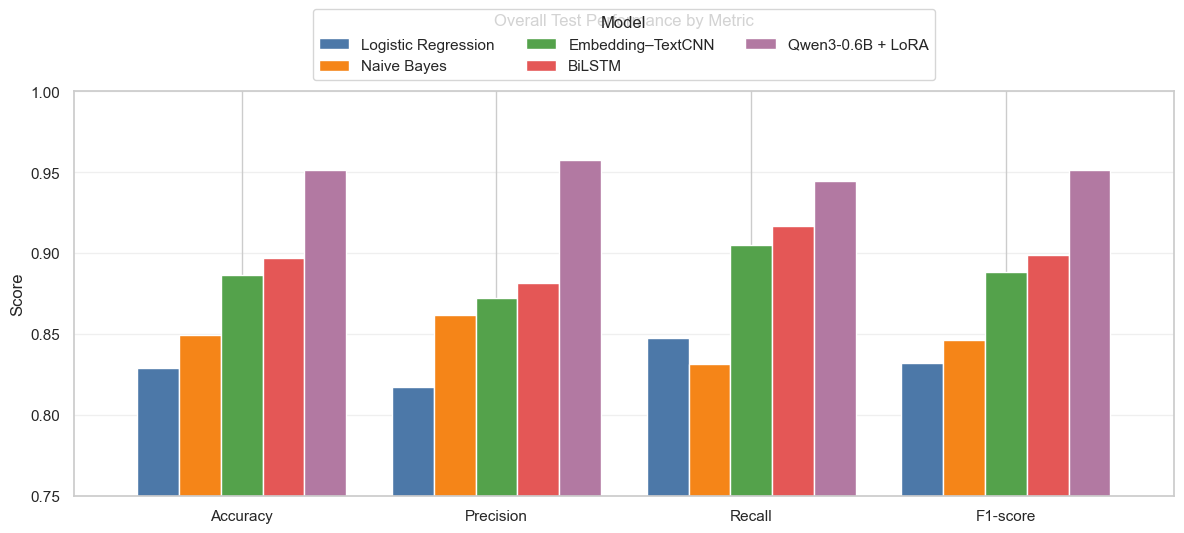

In [25]:
overall_metrics = pd.DataFrame(
    {
        "Accuracy": [0.8289, 0.8492, 0.8863, 0.8968, 0.9514],
        "Precision": [0.8172, 0.8620, 0.8722, 0.8817, 0.9575],
        "Recall": [0.8474, 0.8314, 0.9053, 0.9165, 0.9448],
        "F1-score": [0.8320, 0.8464, 0.8884, 0.8988, 0.9511],
    },
    index=[
        "Logistic Regression",
        "Naive Bayes",
        "Embedding–TextCNN",
        "BiLSTM",
        "Qwen3-0.6B + LoRA",
    ],
)

# Transpose: group bars by Accuracy, Precision, Recall and F1
ax = overall_metrics.T.plot(
    kind="bar",
    figsize=(12, 5.5),
    width=0.82,
    color=[
        "#4C78A8",
        "#F58518",
        "#54A24B",
        "#E45756",
        "#B279A2",
    ],
)

ax.set_ylim(0.75, 1.00)
ax.set_title("Overall Test Performance by Metric", pad=48)
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.tick_params(axis="x", rotation=0)

ax.legend(
    title="Model",
    ncol=3,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
)

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.1.3 Main Cross-model Observations

- **Qwen3-0.6B with LoRA achieved the strongest result**, with 95.14% accuracy and a 95.11% F1-score. Its F1-score was 5.23 percentage points higher than the best non-LLM model.
- **BiLSTM was the strongest non-LLM method**, reaching an F1-score of 89.88%. It exceeded Embedding–TextCNN by 1.04 percentage points.
- **Embedding–TextCNN remained competitive**, achieving 88.84% F1 and showing that controlled embedding pretraining can substantially improve a compact convolutional classifier.
- **Naive Bayes outperformed Logistic Regression** by 1.44 percentage points in F1-score, indicating that its unigram–bigram representation captured useful local phrase information.
- The neural models generally achieved higher recall than precision, whereas the final LoRA model produced the strongest precision and the most balanced high-level performance.

## 5.2 Logistic Regression Results

### 5.2.1 Hyperparameter Selection

The loss curve can be seen below:

<img src="./LR/pic/LR_Loss_curve.jpg" width="600">

The loss curve shows the training loss of the final Logistic Regression model. The loss decreases steadily and converges after approximately 300 epochs, indicating stable optimisation under the selected hyperparameters.

|Learning Rate|Lambda|Final Loss|Validation Accuracy|
|---|---|---|---|
|0.5|0.1|0.691020|0.777400|
|0.5|0.01|0.574286|0.783600|
|0.5|0.001|0.624774|0.790600|
|1.0|0.1|0.690967|0.776000|
|1.0|0.01|0.673822|0.784400|
|1.0|0.001|0.598735|0.804600|
|5.0|0.1|0.690962|0.779600|
|5.0|0.01|0.673333|0.785800|
|5.0|0.001|0.579378|0.827600|

Based on the training result using different hyperparameters, the learning rate and L2 regularisation strength were selected using the validation set. Nine combinations of hyperparameters were evaluated, and the model with the highest validation accuracy was chosen for the final classifier. The optimal configuration was a learning rate of 5.0, an L2 regularisation coefficient of 0.001, and 306 training epochs.





### 5.2.2 Final Model Performance

The final Logistic Regression model was retrained using the complete labelled training set with the selected hyperparameters and evaluated on the official test set.

| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| LR | 0.828880 | 0.817158 | 0.847360 | 0.831985 |

The final model achieved an accuracy of 82.89% and an F1-score of 83.20% on the official test set. The relatively balanced precision and recall indicate that the classifier performs consistently across both sentiment classes without favouring either positive or negative reviews.

### 5.2.3 Most Important Sentiment-associated Features

The Logistic Regression classifier assigns a weight to every TF-IDF feature. Positive weights increase the probability of predicting a positive review, whereas negative weights favour the negative class. Table below lists the most influential sentiment-associated features learned by the model.

| Positive Feature | Weight | Negative Feature | Weight |
|:-----------------|-------:|:-----------------|-------:|
| great | 1.8877 | bad | -2.4760 |
| and | 1.5430 | worst | -1.6832 |
| best | 1.1307 | no | -1.3992 |
| love | 1.0976 | waste | -1.1644 |
| excellent | 1.0466 | awful | -1.1536 |
| very | 0.9478 | even | -1.0848 |
| well | 0.9240 | nothing | -1.0139 |
| wonderful | 0.8930 | boring | -1.0053 |
| also | 0.7317 | just | -0.9861 |
| loved | 0.7199 | terrible | -0.9672 |

Strong positive words such as *great*, *love* and *excellent* received large positive weights, while words such as *bad*, *worst* and *terrible* received large negative weights. This demonstrates that the classifier successfully learned meaningful sentiment-related vocabulary from the training data.

However, several neutral or non-sentiment words, such as *and*, *even* and *nothing*, also received relatively large weights. This suggests that the TF-IDF + Logistic Regression model learns statistical correlations from the training data rather than fully understanding semantic meaning. As a result, the classifier may assign importance to frequently co-occurring words that carry little sentiment information, which is a common limitation of bag-of-words based representations.

Logistic Regression assigns a weight to every TF-IDF feature, allowing the learned decision process to be interpreted. Words with positive weights increase the probability of predicting a positive review, whereas words with negative weights favour the negative class. Strong positive words such as great, love and excellent received large positive weights, while negative words such as bad, worst and terrible received large negative weights. This indicates that the classifier successfully learned meaningful sentiment-related vocabulary from the training data.

## 5.3 Naive Bayes Results

### 5.3.1 Validation-based Feature Selection

Two feature settings were compared using validation F1-score. The unigram-plus-consecutive-bigram setting was selected for the final model because it achieved the stronger validation performance.
| Feature setting | n-gram range | Validation accuracy | Validation F1 | Vocabulary size |
|---|---|---:|---:|---:|
| Unigram + consecutive bigram | (1, 2) | 0.8570 | 0.8558 | 20,000 |
| Unigram only | (1, 1) | 0.8410 | 0.8353 | 20,000 |

### 5.3.2 Final Test Performance

The final Multinomial Naive Bayes model was trained using the selected feature setting and evaluated on the untouched official test set.

| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| Multinomial Naive Bayes | 0.8492 | 0.8620 | 0.8314 | 0.8464 |

![Naive Bayes confusion matrix](./Naive_bayes/pic/naive_bayes_cmatrix.png)

### 5.3.3 Word-order Shuffle Experiment

To examine whether consecutive bigram features use local word order, the words in each test review were shuffled while preserving the original words and labels.

| Test condition | Accuracy | Precision | Recall | F1-score_change_from_original |
|---|---:|---:|---:|---:|
| Original review | 0.8492 | 0.8620 | 0.8314 | 0.8464 | 0.0000 |
| Words shuffled | 0.8217 | 0.8324 | 0.8056 | 0.8188 | -0.0276 |
				


Performance decreased after word shuffling, indicating that the selected bigram features capture some local word-order information. However, the model still represents reviews primarily as bag-of-words/count features and cannot fully model long-range context

### 5.3.4 Important Sentiment-associated Features

The model assigns feature scores according to the difference between their class-specific log probabilities. To reduce the influence of rare terms, only features appearing in at least 20 training reviews were considered.

| Positive feature | Score | Document frequency | Negative feature | Score | Document frequency |
|---|---:|---:|---|---:|---:|
| *edie* | 4.6959 | 40 | *this garbage* | -4.3484 | 72 |
| *antwone* | 4.4841 | 24 | *terrible movie* | -4.2241 | 67 |
| *gunga din* | 4.1698 | 23 | *worst films* | -4.0119 | 107 |
| *midnight cowboy* | 3.4454 | 31 | *this crap* | -3.9364 | 145 |
| *felix* | 3.1567 | 49 | *worst movies* | -3.7230 | 204 |

These features are strongly associated with negative reviews in the training data. However, some highly weighted features are movie-specific names or titles, indicating that the model may learn dataset-specific correlations rather than general semantic meaning.

## 5.4 Embedding–TextCNN Results

Four embedding conditions were evaluated using the same TextCNN architecture and labelled training data. Therefore, differences in performance primarily reflect the effect of the embedding initialisation and pre-training strategy.

| Embedding condition               | Validation F1 | Test accuracy | Test precision | Test recall |    Test F1 |
| --------------------------------- | ------------: | ------------: | -------------: | ----------: | ---------: |
| Random                            |        0.8540 |        0.8544 |         0.8534 |      0.8559 |     0.8547 |
| Semantic-only                     |    **0.8894** |        0.8849 |     **0.8752** |      0.8978 |     0.8863 |
| Semantic + Sentiment              |        0.8858 |        0.8772 |         0.8618 |      0.8985 |     0.8798 |
| Semantic + Sentiment + Unlabelled |        0.8877 |    **0.8863** |         0.8722 |  **0.9053** | **0.8884** |

The Semantic + Sentiment + Unlabelled condition achieved the highest test accuracy, recall, and F1-score. The Semantic-only condition obtained the highest validation F1-score and test precision. All three pretrained conditions outperformed random initialisation across every reported test metric.

All pretrained embedding conditions improved both accuracy and F1-score compared with random initialisation. The Semantic + Sentiment + Unlabelled condition produced the largest improvements, increasing accuracy by 3.19 percentage points and F1-score by 3.38 percentage points. Semantic-only achieved similar performance, while Semantic + Sentiment without additional unlabelled data produced smaller but still clear improvements over the random baseline.

To qualitatively examine the learned embedding spaces, the eight nearest neighbours of the word excellent were retrieved under each condition.

| Embedding condition               | Nearest neighbours of *excellent*                                                    |
| --------------------------------- | ------------------------------------------------------------------------------------ |
| Random                            | wondered, phil, window, gritty, obnoxious, integrity, nights, cooper                 |
| Semantic-only                     | superb, perfect, rate, outstanding, highly, strong, impressed, underrated            |
| Semantic + Sentiment              | superb, outstanding, brilliant, underrated, rate, fantastic, highly, performances    |
| Semantic + Sentiment + Unlabelled | outstanding, superb, exceptional, superbly, flawless, fantastic, highly, recommended |

The randomly initialised condition produced mostly unrelated neighbouring words. In contrast, all pretrained conditions placed excellent near words with similar semantic or sentiment information. The Semantic + Sentiment + Unlabelled condition produced the most consistently positive neighbours, including exceptional, flawless, fantastic, and recommended. This qualitative result is consistent with its strong downstream classification performance.

## 5.5 BiLSTM Results

This section reports the quantitative and visual outputs of the final BiLSTM baseline. The goal is not just to show the files, but to explain what the training curves, final metrics, and confusion matrix suggest about the model's behavior.

### 5.5.1 Training and validation loss
The training-versus-validation loss curve shows that optimization behaved sensibly in the early epochs, but it also reveals some overfitting later in training. Training loss decreases steadily throughout the run, while validation loss falls quickly at first and reaches its lowest point around epoch 5. After that point, validation loss begins to rise and fluctuate even though training loss continues to improve.

This pattern suggests that the model learns useful sentiment representations early, but continued training starts to fit the training split more strongly than the validation split. Therefore, the best checkpoint should be selected from the validation signal rather than from the final training epoch.

![lstm_baseline_train_val_loss.png](./BiLSTM/outputs/figures/lstm_baseline_train_val_loss.png)

### 5.5.2 Validation accuracy
The validation accuracy curve rises quickly during the first few epochs, moving from roughly 0.80 at the start to close to 0.89 by the middle of training. It then improves more gradually and reaches its highest point around epoch 8 before declining slightly toward the end of the run.

Because IMDb is a balanced binary dataset, this accuracy trend is a useful high-level indicator that the BiLSTM is learning meaningful sentiment structure. The slight late decline is consistent with the validation-loss curve: the model continues to optimize the training objective, but validation performance no longer improves after the best checkpoint region.

![lstm_baseline_val_accuracy.png](./BiLSTM/outputs/figures/lstm_baseline_val_accuracy.png)

### 5.5.3 Validation F1
Validation F1 follows a similar pattern to validation accuracy. It improves rapidly in the early epochs, peaks around epoch 8, and then drops slightly in the final epochs. This is a useful confirmation because F1 combines precision and recall rather than only measuring the overall fraction of correct predictions.

The close agreement between the validation accuracy and F1 curves suggests that the selected BiLSTM checkpoint is not relying on a severe class imbalance effect. Instead, the model appears to make broadly balanced progress on the binary classification task, with the main remaining issue being the precision-recall tradeoff examined in the final test results.


![lstm_baseline_val_f1.png](./BiLSTM/outputs/figures/lstm_baseline_val_f1.png)

### 5.5.4 Final test metrics
The final held-out test metrics show that the BiLSTM baseline performs strongly overall. According to the saved result file, the model reaches **accuracy = 0.89676**, **precision = 0.88171**, **recall = 0.91648**, **F1 = 0.89876**, and **loss = 0.30583**.

The most interesting part of this result is the relationship between precision and recall. Recall is higher than precision, which means the model is better at finding positive reviews than at avoiding false positive predictions. This matches the confusion matrix: there are **1,537 false positives** and **1,044 false negatives**. Even with this imbalance, the F1-score remains close to 0.90, so the final result is strong for a compact recurrent baseline.


In [21]:
import json

metrics_path = Path('./BiLSTM/outputs/results/lstm_baseline_metrics.json')
with metrics_path.open('r', encoding='utf-8') as file_handle:
    metrics = json.load(file_handle)

metrics_df = pd.DataFrame(
    [{'metric': key, 'value': value} for key, value in metrics.items()]
)
metrics_df

,metric,value
0,accuracy,0.896760
1,precision,0.881706
2,recall,0.916480
3,f1,0.898757
4,loss,0.305831


### 5.5.5 Confusion matrix and error patterns
The confusion matrix helps move from aggregate scores to class-level behavior. The model correctly classifies most reviews in both classes, with **10,963 true negatives** and **11,456 true positives** out of 25,000 balanced test examples. The error counts are smaller but asymmetric: **1,537 negative reviews are predicted as positive**, while **1,044 positive reviews are predicted as negative**.

This class-level pattern reinforces the precision-recall interpretation above. The model is somewhat more willing to assign the positive label, which raises recall but lowers precision. In practical terms, the BiLSTM is effective at detecting positive sentiment evidence, but some negative reviews with local praise, mixed wording, or ambiguous tone are still pushed into the positive class.

![lstm_baseline_confusion_matrix.png](./BiLSTM/outputs/figures/lstm_baseline_confusion_matrix.png)

## 5.6 LLM Results

Every setting was evaluated on all **25,000 test reviews**. Overall accuracy is the primary metric; invalid generations count as errors. Valid-output coverage is reported separately, along with valid-only accuracy, positive-class precision/recall/F1, macro F1, and confusion matrices.

Prompting ran in float16 on a Tesla T4. LoRA training and adapted-model evaluation ran in bfloat16 on an RTX 3070 Laptop GPU. Consequently, time per review is an operational record, **not a controlled speed comparison**. The prompting and LoRA review-token budgets also differ (900 versus 430), so performance gains cannot be attributed to latency or context length.

#### Main quantitative comparison
| Setting | Overall accuracy | Valid-only accuracy | Coverage | Precision (+) | Recall (+) | F1 (+) | Invalid |
|---|---:|---:|---:|---:|---:|---:|---:|
| Zero-shot | **83.776%** | 84.350% | 99.320% | 77.434% | **96.990%** | 86.116% | 170 |
| Few-shot | **89.480%** | 89.491% | 99.988% | 85.399% | 95.272% | 90.065% | 3 |
| LoRA fine-tuned | **95.144%** | 95.144% | 100.000% | **95.752%** | 94.480% | **95.112%** | 0 |

![Grouped comparison of accuracy, positive F1 and coverage](./Qwen3_0.6B_IMDB/final_result/qwen3_results_comparison.png)

Few-shot prompting improved overall accuracy by **5.704 percentage points** over zero-shot. LoRA added another **5.664 points**, reaching 95.144% with complete output coverage.

### Confusion matrices and class balance

![Confusion matrices for zero-shot, few-shot and LoRA settings](./Qwen3_0.6B_IMDB/final_result/qwen3_confusion_matrices.png)

The prompt-only models were biased toward the positive class. In zero-shot inference, positive recall was 96.99%, but negative recall was only 71.69%, producing **3,512 false positives**. Two balanced demonstrations reduced false positives to **2,036** and raised negative recall to 83.71%.

LoRA produced a substantially more symmetric error profile: negative recall reached **95.81%**, positive recall was **94.48%**, and macro F1 was **95.14%**. False positives fell to **524**, an 85.1% reduction from zero-shot. The trade-off is visible: false negatives increased from 374 (zero-shot) to 690 (LoRA), so the gain came from correcting the large positive bias rather than increasing every class-specific metric.

#### Result interpretation

- **Demonstrations help both the decision boundary and format compliance.** Few-shot inference reduced invalid generations from 170 to 3 and reduced total errors from 4,056 to 2,630 (35.2%).
- **Supervised adaptation is the decisive improvement.** LoRA reduced total errors to 1,214: 53.8% fewer than few-shot and 70.1% fewer than zero-shot. It also eliminated invalid labels.
- **Precision-recall balance changed meaningfully.** Positive recall declined slightly across the three settings, while positive precision rose from 77.43% to 95.75%. For a balanced binary task, the much higher negative recall and macro F1 make LoRA's behaviour more useful than the recall-heavy zero-shot baseline.
- **Few-shot inference has a context cost.** Mean prompt length increased from 316.4 to 839.4 tokens, and recorded latency rose from 0.0694 to 0.1374 seconds per review on the same T4. The two examples therefore buy accuracy without training, but roughly double inference time in this run.

No state-of-the-art claim is made because external systems were not reproduced under identical data handling and hardware.

### Fine-tuning behaviour and efficiency

| Training outcome | Saved result |
|---|---:|
| Steps / epochs | 625 / 1 |
| Training time | 12,708.6 s (211.81 min) |
| Aggregate training loss | 0.05608 |
| Final validation loss | 0.04931 |
| Trainable / total parameters | 5,046,272 / 601,096,192 |
| Trainable proportion | 0.8395% |
| Adapter weights | 19.30 MB |

The low validation loss is consistent with the strong test result, while parameter efficiency is the practical advantage: the base weights remain frozen and only a small adapter must be stored. However, validation was performed at the end of the single epoch, so the run does not establish a full learning curve or prove that this epoch count is optimal. The 211.8-minute adaptation cost is also a real disadvantage when a prompt-only solution is sufficient.

### Word-cloud error analysis

Word clouds were generated from the LoRA model's **524 false-positive** and **690 false-negative** review previews. HTML was removed, English words were retained, common stop words and high-frequency domain words such as `movie`, `film`, and `character` were excluded, collocations were disabled, and random seed 42 was used.

| False positives: actual negative, predicted positive | False negatives: actual positive, predicted negative |
|---|---|
| ![False-positive review word cloud](./Qwen3_0.6B_IMDB/final_result/qwen3_wordcloud_false_positive.png) | ![False-negative review word cloud](./Qwen3_0.6B_IMDB/final_result/qwen3_wordcloud_false_negative.png) |

#### What the word clouds show

| Rank | False-positive words | Relative frequency | False-negative words | Relative frequency |
|---:|---|---:|---|---:|
| 1 | good | 1.000 | good | 1.000 |
| 2 | time | 0.813 | time | 0.903 |
| 3 | story | 0.658 | show | 0.810 |
| 4 | well | 0.592 | first | 0.713 |
| 5 | great | 0.529 | people | 0.690 |
| 6 | first | 0.508 | bad | 0.653 |
| 7 | way | 0.504 | story | 0.646 |
| 8 | bad | 0.496 | scene | 0.646 |
| 9 | movies | 0.479 | well | 0.638 |
| 10 | two | 0.454 | know | 0.575 |

Both error groups are dominated by overlapping words such as **good**, **time**, **story**, **well**, and **bad**. This overlap is the important result: isolated sentiment words are insufficient to separate the two error types. False positives contain locally positive cues (`good`, `great`, `love`) inside reviews whose overall judgement is negative, while false negatives still contain negative descriptions (`bad`, `plot`, `horror`) inside reviews labelled positive. This is consistent with contrast, mixed sentiment, and discussion of disliked subcomponents confusing the model.

The analysis is descriptive rather than causal. A word cloud ignores word order, negation, intensity and sentence-level contrast; moreover, the saved prediction file contains only the first **1,000 cleaned characters** of each review. It should therefore motivate a targeted qualitative error taxonomy, not be treated as a feature-importance explanation.

### Review summarisation (supplementary)

The base Qwen3-0.6B model was also tested qualitatively on **10 test reviews** selected after shuffling with seed 42. It was prompted to produce one or two sentences focused on the reviewer's main opinion and reasons; thinking and sampling were disabled, with `max_new_tokens=80`. Outputs were manually checked for sentiment preservation, main-opinion and reason coverage, factual accuracy, and information prioritisation. The full saved outputs are available in [imdb_review_summaries.csv](./Qwen3_0.6B_IMDB/final_result/imdb_review_summaries.csv).

| Manual assessment | Reviews |
|---|---:|
| Good | 5 |
| Fairly good | 2 |
| Average | 1 |
| Poor | 2 |

<br>

| Review | Condensed generated output | Assessment |
|---:|---|---|
| 1 | The movie *A Thousand Acres* was a deeply moving and emotionally resonant experience, with a compassionate portrayal of sisterhood and an impact on the viewer's personal growth. | Good: preserves sentiment and central impact. |
| 7 | The reviewer expresses a positive opinion, highlighting the tragic child-abuse story while describing the unexpected ending as a point of sadness. | Poor: the reviewer actually criticised the ending as implausible. |
| 9 | Gregory Dark's cheesy horror flick, *Glen Jacobs*, is a disappointing D-grade production with a weak plot and execution. | Poor: Glen Jacobs is an actor, not the film title. |

Seven of the ten summaries were rated at least fairly good. The model usually preserved sentiment and produced concise, fluent text, but the two poor cases show that fluency does not guarantee faithfulness: it can misread the reviewer's reasoning or assign the wrong role to a named entity. Because this was a small qualitative test without reference summaries or automatic metrics, it is supporting evidence rather than a benchmark result.

## 5.7 Cross-model Error Analysis

The model-specific analyses reveal several recurring sources of error. They also show how different representations fail in different ways.

| Error pattern | Evidence in the results | Most directly affected methods |
|---|---|---|
| Surface correlation and dataset-specific cues | Logistic Regression assigned large weights to some neutral tokens, while Naive Bayes ranked several movie titles and character names as highly predictive. | Logistic Regression; Naive Bayes |
| Mixed or contrastive sentiment | BiLSTM false positives often contained local praise inside an overall negative review. The LoRA word clouds also showed substantial overlap between words such as *good*, *bad*, *story* and *well* across both error classes. | BiLSTM; Qwen3; likely relevant to all models |
| Positive prediction bias | BiLSTM produced 1,537 false positives versus 1,044 false negatives. Zero-shot Qwen3 showed a larger version of the same bias, although few-shot prompting and LoRA substantially reduced it. | BiLSTM; zero-shot and few-shot Qwen3 |
| Long reviews and information compression | TextCNN keeps the strongest local convolution responses, BiLSTM compresses the sequence through max pooling, and Qwen3 uses a finite review-token budget. Decisive evidence may therefore be underweighted or truncated. | Neural and LLM methods |
| Rare and out-of-vocabulary expressions | 84.77% of raw token types occurred at most five times, while each method used a limited vocabulary or token budget. Rare names, misspellings and uncommon sentiment expressions remain difficult to model reliably. | All methods |

Overall, the available evidence indicates that strong isolated words are not sufficient when the review contains negation, contrast, sarcasm or mixed opinions. Context-aware models reduce many lexical errors, but they do not eliminate ambiguity or the loss of information caused by pooling and truncation. Because the models' prediction files were not joined review by review, this section does not claim that the same individual reviews were misclassified by every model; it identifies patterns supported by the separate analyses.

# 6. Discussion

## 6.1 Comparison Across All Models

The overall results show a clear performance progression from sparse lexical models to neural sequence models and finally to supervised LLM adaptation. Logistic Regression established the simplest baseline with an F1-score of 0.8320. Multinomial Naive Bayes improved this to 0.8464 by including consecutive bigrams, suggesting that limited local word order was useful even without dense representations. Both methods remain attractive when low training cost, fast inference and feature-level interpretability are more important than maximum accuracy.

Embedding–TextCNN and BiLSTM produced a second performance tier, with F1-scores of 0.8884 and 0.8988 respectively. The embedding ablation provides controlled evidence that representation quality matters: the strongest pretrained condition improved TextCNN F1 by 3.37 percentage points over random initialisation. BiLSTM then exceeded the best TextCNN setting by 1.04 percentage points, consistent with the value of contextual sequence modelling for longer reviews. 

LoRA-adapted Qwen3-0.6B achieved the best result, reaching 0.9514 accuracy and 0.9511 F1. Its F1-score was 5.23 percentage points above BiLSTM, and its confusion matrix was substantially more balanced than the zero-shot and few-shot variants. This result demonstrates the value of supervised adaptation on top of a pretrained language model. The gain comes with important costs: LoRA training required approximately 211.8 minutes in the recorded run, deployment still requires the 601-million-parameter base model, and generative classification needs explicit output parsing.

The best model therefore depends on the deployment objective. Qwen3-0.6B with LoRA is preferred when predictive performance is the main priority. BiLSTM or Embedding–TextCNN provides a stronger balance between performance and model scale, while Naive Bayes and Logistic Regression remain useful transparent baselines. 

## 6.2 Logistic Regression Discussion

The proposed Logistic Regression baseline achieved an accuracy of 82.89% and an F1-score of 83.20% on the official test set. The balanced precision and recall indicate that the classifier can effectively distinguish positive and negative movie reviews while maintaining stable overall performance.

The combination of TF-IDF and Logistic Regression provides a simple yet effective baseline for sentiment classification. TF-IDF assigns larger weights to informative words, while Logistic Regression learns a linear decision boundary based on these weighted features. As shown by the learned feature weights, strongly positive words such as great and excellent received positive coefficients, whereas words such as bad and terrible were assigned negative coefficients, demonstrating that the model successfully captured sentiment-related vocabulary.

However, several neutral words, such as and, even and nothing, also received relatively large weights. This indicates that the classifier learns statistical correlations from the training data rather than genuine semantic meaning. Consequently, it may assign excessive importance to words with little sentiment information, reducing its ability to generalise to unseen reviews and contributing to misclassification when contextual understanding is required. Combined with the bag-of-words nature of TF-IDF, the model cannot effectively capture contextual information, word order or complex linguistic patterns such as negation.

## 6.3 Naive Bayes Discussion

The Multinomial Naive Bayes model achieved an accuracy of 0.8492 and an F1-score of 0.8464 on the test set. The model was computationally efficient, with feature vectorisation accounting for most of the processing time.

The unigram-plus-bigram representation outperformed unigram features during validation. When word order was shuffled, the F1-score decreased from 0.8464 to 0.8188, indicating that consecutive bigrams captured useful local word-order patterns.

The feature analysis identified clear negative expressions, such as *terrible movie* and *this garbage*, as strongly associated with negative sentiment. However, several highly weighted positive features were movie titles or character names rather than general positive expressions. This indicates that the model learned statistical correlations from the training data rather than genuine semantic meaning. Its count-based representation also cannot fully model long-range dependencies, negation, or sarcasm. 

Therefore, Naive Bayes provides an efficient and interpretable baseline, while more context-aware models may perform better on complex reviews.

## 6.4 Embedding–TextCNN Discussion
The results demonstrate that embedding pre-training provides a more effective starting point for TextCNN than random initialisation. All three pretrained conditions improved every test metric, indicating that learning word relationships before classifier training helps the model extract sentiment-relevant patterns from reviews.

The strong performance of Semantic-only shows that explicit sentiment labels are not essential for learning useful representations. Words occurring in similar contexts can develop related vectors, allowing the classifier to recognise meaningful phrases and review patterns more easily. This condition achieved the highest validation F1-score and test precision.

Adding sentiment supervision did not automatically improve performance. Semantic + Sentiment without unlabelled data performed worse than Semantic-only. One possible reason is that review-level sentiment labels provide relatively coarse supervision: a positive review may still contain neutral or negative words, so applying its overall label during embedding training may introduce noise. In addition, this condition had access to less text for semantic learning because it excluded the additional unlabelled reviews.

When unlabelled data was included alongside both objectives, performance improved across all test metrics compared with Semantic + Sentiment alone. Test F1 increased from 0.8798 to 0.8884, suggesting that the broader semantic context provided by the unlabelled reviews helped stabilise the sentiment-supervised embedding space.

Compared with Semantic-only, the final joint condition produced a small increase in accuracy and F1-score but shifted the precision–recall balance. Recall increased from 0.8978 to 0.9053, while precision decreased from 0.8752 to 0.8722. This suggests that sentiment supervision made the classifier more sensitive to positive-class examples, reducing missed positive reviews at the cost of slightly more false-positive predictions.

Overall, the results suggest that semantic pre-training provides most of the improvement over random initialisation, while sentiment supervision offers a smaller additional benefit when combined with sufficient unlabelled text. Therefore, the main value of the final method comes from integrating broad semantic learning with task-specific sentiment information

## 6.5 BiLSTM Discussion

This section interprets the BiLSTM result rather than merely repeating it. The aim is to connect the strengths and weaknesses of the model back to the structure of the IMDb dataset and to the design choices used in the final pipeline.

### 6.5.1 What worked well
Overall, the BiLSTM baseline works well for this task. The held-out accuracy and F1-score are both close to 0.90, which shows that the model is capturing meaningful sentiment information rather than relying only on superficial word overlap. The recurrent encoder, masking, and pooling stages also work together cleanly, so the full preprocessing-to-prediction pipeline behaves like a coherent end-to-end text classification system.

Another encouraging sign is the relatively high recall. This suggests that the model is usually able to pick up positive sentiment-bearing evidence in the review, even when the text is long or not perfectly clean. For a compact recurrent baseline, that is a solid outcome.


### 6.5.2 Limitations and weaknesses
At the same time, the model clearly has limitations. The lower precision compared with recall, together with the larger number of false positives than false negatives, suggests that it sometimes predicts positive sentiment too easily. In a dataset like IMDb, that is plausible: many negative reviews still contain praise for particular scenes, actors, or ideas, and those local positive cues can confuse the model when the overall judgement is still negative.

The training curves also show a limitation in generalization. Validation loss reaches its minimum around epoch 5 and then rises while training loss continues to decrease, so later training begins to overfit the training split. The fixed pooled representation is another limitation. Even though max pooling is simple and effective, it still forces a long and sometimes contradictory review into one vector. That means subtle contrast, mixed sentiment, and gradual shifts in tone can be harder to handle cleanly.


### 6.5.3 Error analysis / misclassified examples
The misclassified examples make the weaknesses of the model much easier to understand. There are more false positives than false negatives, which is consistent with the model's higher recall than precision. Many difficult false-positive cases are negative reviews that still contain local positive phrases, praise for individual aspects of a film, or language that is not strongly negative throughout. In examples like these, the model may latch onto positive evidence even though the writer's final judgement is negative.

Another clear pattern is that some reviews are not strongly emotional in a simple way. Instead, they are hedged, mixed, long, or written in a rambling style. False negatives also include long reviews where the positive judgement depends on a broader reading of the full text rather than a few obvious keywords. This is likely where the model is most vulnerable: it can detect many useful sentiment cues, but it is not always reliable at deciding which cues should dominate when the review contains conflicting evidence.


In [22]:
misclassified_path = Path('./BiLSTM/outputs/results/lstm_baseline_misclassified_examples.json')
with misclassified_path.open('r', encoding='utf-8') as file_handle:
    misclassified_examples = json.load(file_handle)

misclassified_df = pd.DataFrame(misclassified_examples)
misclassified_df['error_type'] = misclassified_df.apply(
    lambda row: 'false_positive' if row['true_label'] == 0 and row['predicted_label'] == 1 else 'false_negative',
    axis=1,
)

summary = misclassified_df.groupby('error_type').agg(
    count=('index', 'count'),
    mean_token_count=('token_count', 'mean'),
    median_token_count=('token_count', 'median'),
)
summary

sample_columns = ['error_type', 'true_label', 'predicted_label', 'token_count', 'text']
for error_type in ['false_positive', 'false_negative']:
    sample_df = misclassified_df.loc[misclassified_df['error_type'] == error_type, sample_columns].head(3).copy()
    if not sample_df.empty:
        sample_df['text'] = sample_df['text'].str.slice(0, 400) + '...'
        print(f'\n{error_type.upper()} EXAMPLES')
        display(sample_df)



FALSE_POSITIVE EXAMPLES


,error_type,true_label,predicted_label,token_count,text
0,false_positive,0,1,149,"First off let me say, If you haven't enjoyed a..."
1,false_positive,0,1,299,"Ben, (Rupert Grint), is a deeply unhappy adole..."
2,false_positive,0,1,76,<br /><br />Never ever take a film just for it...



FALSE_NEGATIVE EXAMPLES


,error_type,true_label,predicted_label,token_count,text
1537,false_negative,1,0,574,I finally watched the third film in Mehta's tr...
1538,false_negative,1,0,118,This was a bold movie to hit Indian cinemas wh...
1539,false_negative,1,0,68,For all that has been said about the subject m...


### 6.5.4 Future work beyond the BiLSTM baseline
A natural next step would be to test stronger sequence encoders or attention-based models and compare whether they handle long, mixed-sentiment reviews more cleanly. Even within the recurrent family, it would also be useful to tune the current BiLSTM more systematically and examine whether different hidden sizes, pooling strategies, or regularization settings change the precision-recall tradeoff.

More structured error analysis would also strengthen the discussion. The current examples and confusion matrix already suggest that many failures involve mixed evidence and a tendency toward false positives, but a more systematic breakdown by review length, sentiment ambiguity, and linguistic pattern would make the conclusions more convincing.


## 6.6 LLM Discussion

**Strengths**

- Complete 25,000-review evaluation, with invalid outputs explicitly included in overall accuracy.
- A clear within-model progression from no updates, to demonstrations, to task adaptation.
- LoRA combines high accuracy, balanced class performance, complete output coverage, and less than 1% trainable parameters.
- Deterministic decoding and a fixed parser make the classification protocol easy to audit.
- In the small qualitative test, the base model generally produced concise, fluent summaries that preserved overall sentiment.

**Weaknesses**

- Fine-tuning adds substantial compute time and still requires the base model at deployment.
- Generative one-word classification does not provide calibrated class probabilities.
- Truncation can remove decisive evidence from long or highly structured reviews.
- Prompting results depend on a single fixed demonstration pair, while the word-cloud analysis loses context.
- Review summarisation was tested on only 10 examples and included reasoning and named-entity errors.

### Limitations and future work

The classification experiment uses one seed, one demonstration pair, one LoRA configuration, and one review domain. Prompting and LoRA were evaluated with different token budgets and GPUs, so latency is not directly comparable. The training run also provides only one epoch-end validation point. The summarisation extension is qualitative, uses only 10 examples, and has no reference-based metric.

The most useful next steps are to:

1. repeat multiple seeds and several balanced demonstration pairs, reporting mean and variance;
2. compare all three settings on the same GPU and context budget;
3. score the `positive` and `negative` label-token log-likelihoods instead of relying on free generation;
4. ablate LoRA rank, review-token budget, learning rate, and epoch count;
5. manually code a stratified error sample for negation, sarcasm, contrast, mixed sentiment and truncation effects;
6. evaluate summarisation on a larger annotated sample with independent human ratings and faithfulness checks; and
7. test out-of-domain customer feedback to measure transfer beyond movie reviews.

# 7. Conclusion

This project compared five approaches to binary IMDb sentiment classification: Logistic Regression, Multinomial Naive Bayes, Embedding–TextCNN, BiLSTM and Qwen3-0.6B with LoRA. Performance generally increased as the models gained richer text representations and stronger contextual modelling. Logistic Regression achieved an F1-score of 0.8320, Naive Bayes reached 0.8464, the best TextCNN condition reached 0.8884, BiLSTM reached 0.8988, and LoRA-adapted Qwen3-0.6B achieved the highest F1-score of 0.9511.

The embedding ablation showed that semantic pretraining produced most of TextCNN's improvement over random initialisation. Sentiment supervision alone did not guarantee a further gain, but combining it with additional unlabelled semantic data produced the strongest TextCNN result. Across the wider comparison, recurrent and language-model approaches handled contextual information more effectively than sparse lexical baselines, although mixed sentiment, contrast, rare expressions and long-review compression remained important sources of error.

Overall, Qwen3-0.6B with LoRA provided the best predictive performance, while the other models retained advantages in simplicity, interpretability or computational requirements. These results support choosing a model according to both accuracy and deployment constraints rather than treating test performance as the only criterion.